<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
    EDA-energy-consumption-analysis
</center></p></h1>

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">1️⃣ Step 1 | About Dataset </font><br>
 <br>   
<br>

In [19]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import plotly.subplots as sp
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor



import warnings 
warnings.filterwarnings('ignore')

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [2]:
df = pd.read_csv(r'D:\Data Analysis- Scientist\Mchine Learning\Projects\Dataset for energy\Time series-Energy Consumption\EDA-Energy-consumption-analysis\Energy_consumption_dataset.csv')
df.head()

,Month,Hour,DayOfWeek,Holiday,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption
0,1,0,Saturday,No,25.139433,43.431581,1565.693999,5,On,Off,2.774699,75.364373
1,1,1,Saturday,No,27.731651,54.225919,1411.064918,1,On,On,21.831384,83.401855
2,1,2,Saturday,No,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,78.270888
3,1,3,Saturday,No,20.080469,50.371637,1452.316318,1,Off,On,8.623447,56.519850
4,1,4,Saturday,No,23.097359,51.401421,1094.130359,9,On,Off,3.071969,70.811732


In [3]:
df.head()

,Type_of_Renewable_Energy,Installed_Capacity_MW,Energy_Production_MWh,Energy_Consumption_MWh,Energy_Storage_Capacity_MWh,Storage_Efficiency_Percentage,Grid_Integration_Level,Initial_Investment_USD,Funding_Sources,Financial_Incentives_USD,GHG_Emission_Reduction_tCO2e,Air_Pollution_Reduction_Index,Jobs_Created
0,4,93.423205,103853.2206,248708.4892,2953.248771,89.887562,4,4.732248e+08,1,9.207772e+06,6663.816572,81.742461,1366
1,4,590.468942,190223.0649,166104.1642,5305.174042,84.403343,4,1.670697e+08,2,1.685101e+06,30656.049820,78.139042,1743
2,1,625.951142,266023.4824,424114.6308,2620.192622,60.498249,2,8.463610e+07,2,5.111813e+06,1749.613759,8.461296,363
3,1,779.998728,487039.5296,308337.7316,1925.250307,86.897861,3,3.967690e+08,2,4.805902e+06,43233.237820,8.402441,2821
4,3,242.106837,482815.0856,360437.7705,3948.945383,70.949351,2,3.574413e+07,1,1.668601e+07,14858.662760,28.822867,2583


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Basic Understanding Data  
</center></p></h1>

In [4]:
# -------------------------------
# Basic Info About Dataset
# -------------------------------

print("Shape of dataset:", df.shape)
print("\n")

print("Dataset head:")
print(df.head())
print("\n")

print("Dataset info:")
df.info()
print("\n")

print("Description of numerical columns:")
print(df.describe().transpose())
print("\n")

# -------------------------------
# Checking for Duplicates
# -------------------------------

print("Number of duplicate rows:", df.duplicated().sum())
print("\n")

# -------------------------------
# Column Data Types
# -------------------------------

print("Column data types:")
print(df.dtypes)


Shape of dataset: (5000, 12)


Dataset head:
   Month  Hour DayOfWeek Holiday  Temperature   Humidity  SquareFootage  \
0      1     0  Saturday      No    25.139433  43.431581    1565.693999   
1      1     1  Saturday      No    27.731651  54.225919    1411.064918   
2      1     2  Saturday      No    28.704277  58.907658    1755.715009   
3      1     3  Saturday      No    20.080469  50.371637    1452.316318   
4      1     4  Saturday      No    23.097359  51.401421    1094.130359   

   Occupancy HVACUsage LightingUsage  RenewableEnergy  EnergyConsumption  
0          5        On           Off         2.774699          75.364373  
1          1        On            On        21.831384          83.401855  
2          2       Off           Off         6.764672          78.270888  
3          1       Off            On         8.623447          56.519850  
4          9        On           Off         3.071969          70.811732  


Dataset info:
<class 'pandas.core.frame.DataFrame'>


## Handle missing values

In [3]:
# Check for missing values
df.isnull().sum()

Month                0
Hour                 0
DayOfWeek            0
Holiday              0
Temperature          0
Humidity             0
SquareFootage        0
Occupancy            0
HVACUsage            0
LightingUsage        0
RenewableEnergy      0
EnergyConsumption    0
dtype: int64

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Distribution and anlaysis data
</center></p></h1>

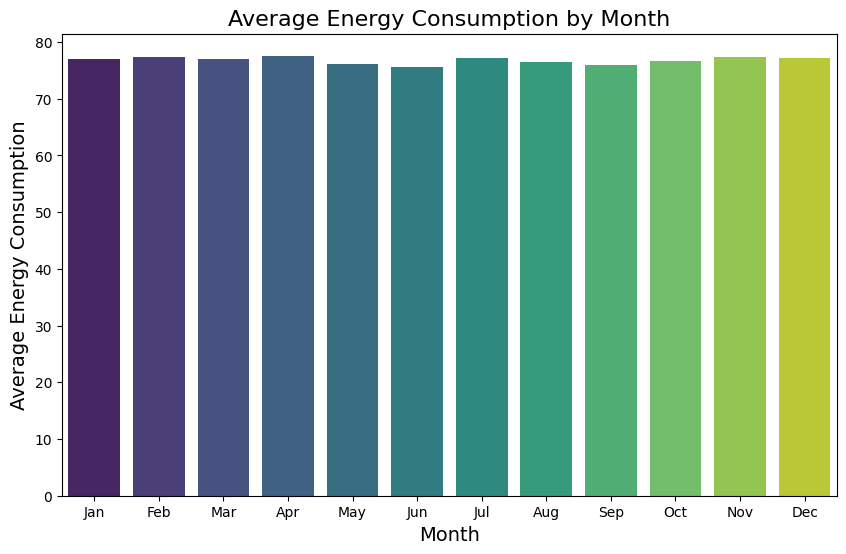

In [5]:
monthly_average_consumption = df.groupby('Month')['EnergyConsumption'].mean().reset_index()
# bar plot
plt.figure(figsize=(10,6))
sns.barplot(x='Month', y= 'EnergyConsumption', data = monthly_average_consumption, palette='viridis')
plt.title('Average Energy Consumption by Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average Energy Consumption', fontsize=14)
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

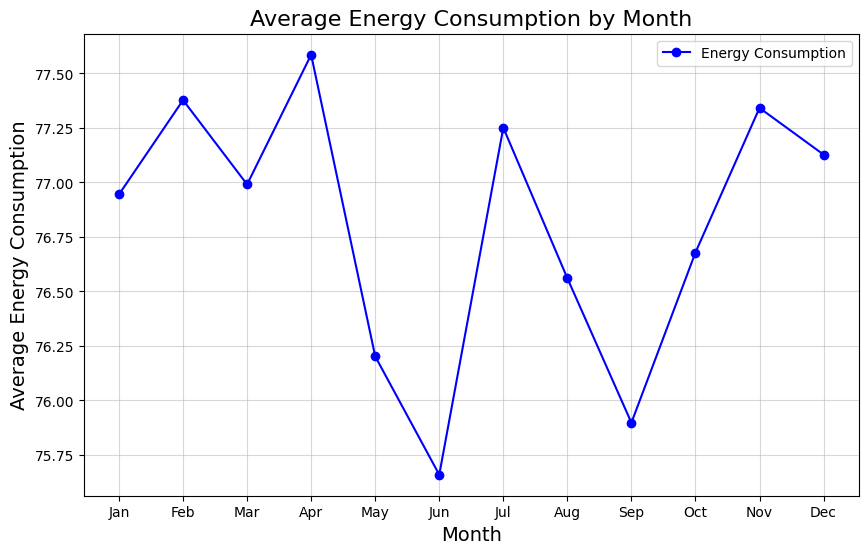

In [6]:
monthly_avg_consumption = df.groupby('Month')['EnergyConsumption'].mean().reset_index()

# Line chart
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg_consumption['Month'], 
         monthly_avg_consumption['EnergyConsumption'], 
         marker='o', color='b', label='Energy Consumption')
plt.title('Average Energy Consumption by Month', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average Energy Consumption', fontsize=14)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(alpha=0.5)
plt.legend()
plt.show()

<div style="border-radius: 5px; font-family: cursive; border: 3px solid #008000; text-align: justify; color: black; font-size: 14px; padding: 10px; background:#F2FFFF;">
  <p>
    The <strong>Average Energy Consumption</strong> values are relatively stable across months, ranging between
    <strong>75</strong> and <strong>79</strong> throughout the year. This indicates that there isn't a significant
    variation in energy consumption based solely on the month.
  </p>

  <p>
    Therefore, creating <strong>dummy variables</strong> for the <strong>Month</strong> column may not add much
    predictive value for our model. Instead, we can either:
  </p>

  <ol>
    <li>
      <strong>Drop the Month column</strong> entirely to reduce model complexity.
    </li>
    <li>
      <strong>Create a new column, "Season"</strong>, to capture potential seasonal patterns by grouping months
      with similar characteristics. This approach helps preserve meaningful insights related to seasonal energy
      consumption behavior.
    </li>
  </ol>
</div>


# Seasonal

In [7]:
def get_season(month):
    if month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    elif month in [9,10]:
        return "Autumn"
    else:
        return "Winter"
    
df["Season"]=df["Month"].apply(get_season)   

In [8]:
df.head()

,Month,Hour,DayOfWeek,Holiday,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,EnergyConsumption,Season
0,1,0,Saturday,No,25.139433,43.431581,1565.693999,5,On,Off,2.774699,75.364373,Winter
1,1,1,Saturday,No,27.731651,54.225919,1411.064918,1,On,On,21.831384,83.401855,Winter
2,1,2,Saturday,No,28.704277,58.907658,1755.715009,2,Off,Off,6.764672,78.270888,Winter
3,1,3,Saturday,No,20.080469,50.371637,1452.316318,1,Off,On,8.623447,56.519850,Winter
4,1,4,Saturday,No,23.097359,51.401421,1094.130359,9,On,Off,3.071969,70.811732,Winter


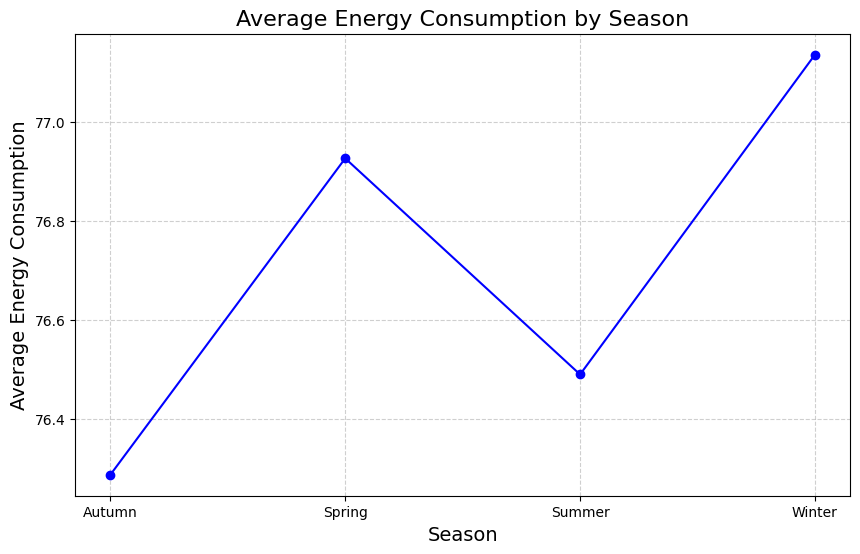

In [9]:
season_avg_consumption = df.groupby('Season')['EnergyConsumption'].mean().reset_index()

#

# Line chart
plt.figure(figsize=(10, 6))
plt.plot(season_avg_consumption['Season'], season_avg_consumption['EnergyConsumption'], marker='o', linestyle='-', color='b')
plt.title('Average Energy Consumption by Season', fontsize=16)
plt.xlabel('Season', fontsize=14)
plt.ylabel('Average Energy Consumption', fontsize=14)
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.show()

# Plot average energy consumption by hour

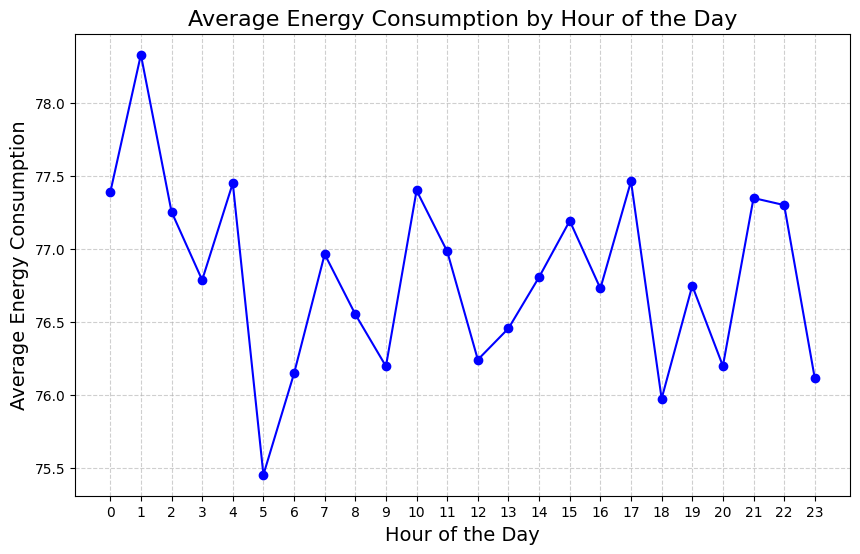

In [10]:
hour_avg_consumption = df.groupby('Hour')['EnergyConsumption'].mean().reset_index()

# Line chart
plt.figure(figsize=(10, 6))
plt.plot(hour_avg_consumption['Hour'], hour_avg_consumption['EnergyConsumption'], marker='o', linestyle='-', color='b')
plt.title('Average Energy Consumption by Hour of the Day', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=14)
plt.ylabel('Average Energy Consumption', fontsize=14)
plt.xticks(range(0, 24))  # Hour range from 0 to 23
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.show()

# Plot distribution of energy consumption


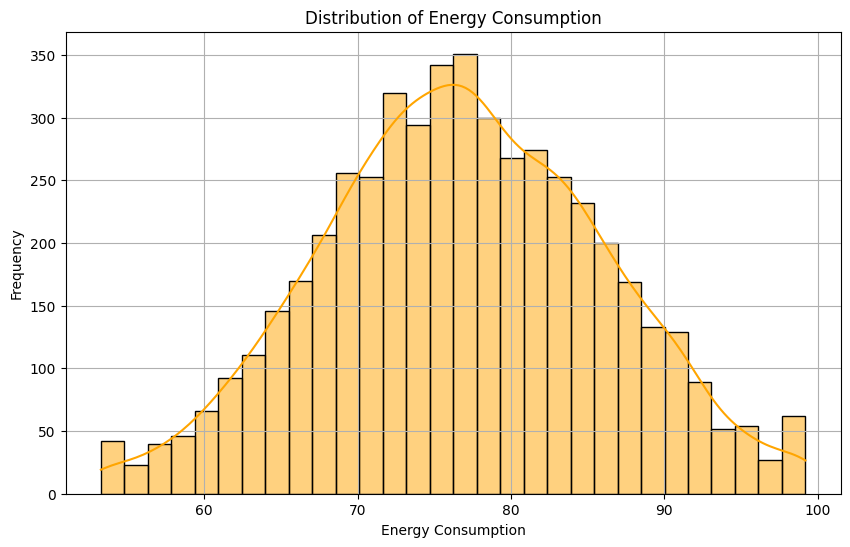

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['EnergyConsumption'], kde=True, color='orange', bins=30)
plt.title('Distribution of Energy Consumption')
plt.xlabel('Energy Consumption')
plt.ylabel('Frequency')
plt.grid()
plt.show()

# Violin plot for Energy Consumption by Hour

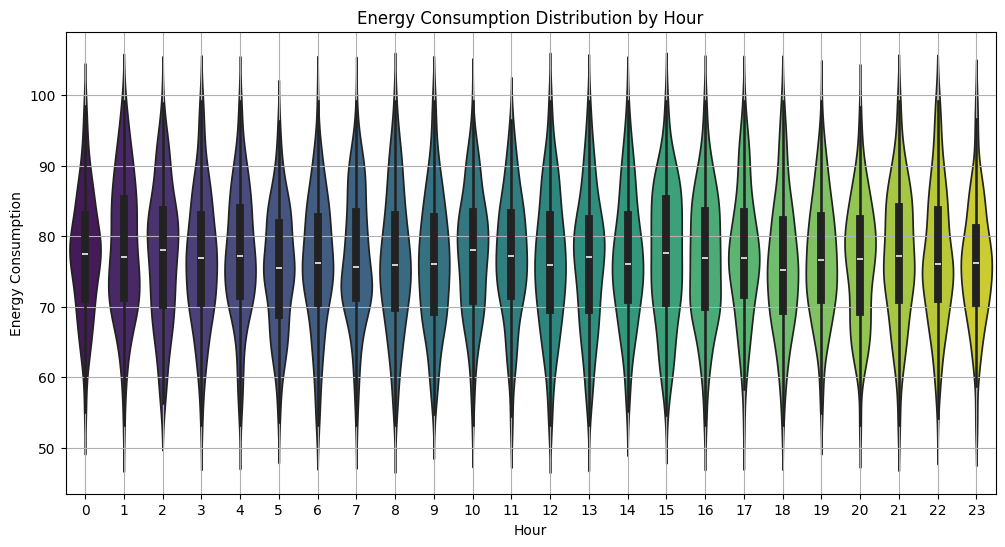

In [15]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Hour', y='EnergyConsumption', palette='viridis', scale='width')
plt.title('Energy Consumption Distribution by Hour')
plt.xlabel('Hour')
plt.ylabel('Energy Consumption')
plt.grid()
plt.show()

# Boxplot for Energy Consumption by Day of the Week


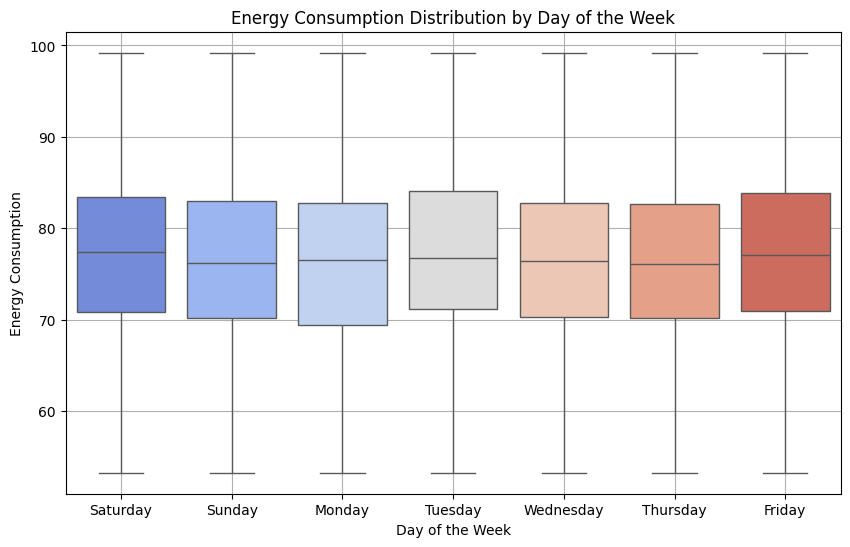

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='DayOfWeek', y='EnergyConsumption', palette='coolwarm')
plt.title('Energy Consumption Distribution by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Energy Consumption')
plt.grid()
plt.show()

# Total Energy Consumption by Month


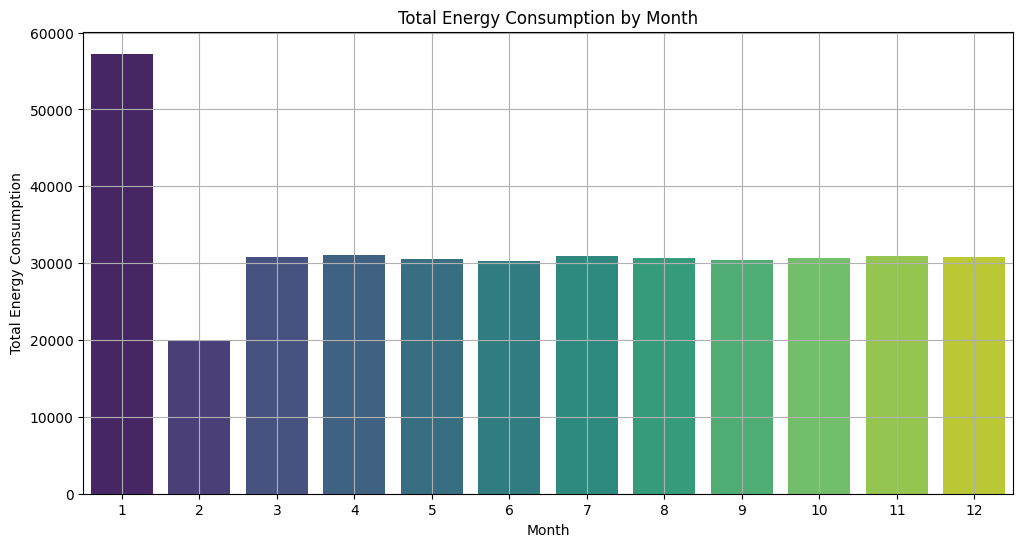

In [16]:
monthly_total = df.groupby('Month')['EnergyConsumption'].sum()

plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_total.index, y=monthly_total.values, palette='viridis')
plt.title('Total Energy Consumption by Month')
plt.xlabel('Month')
plt.ylabel('Total Energy Consumption')
plt.grid()
plt.show()

# Line Plot for Energy Consumption Over Time by Day of Week


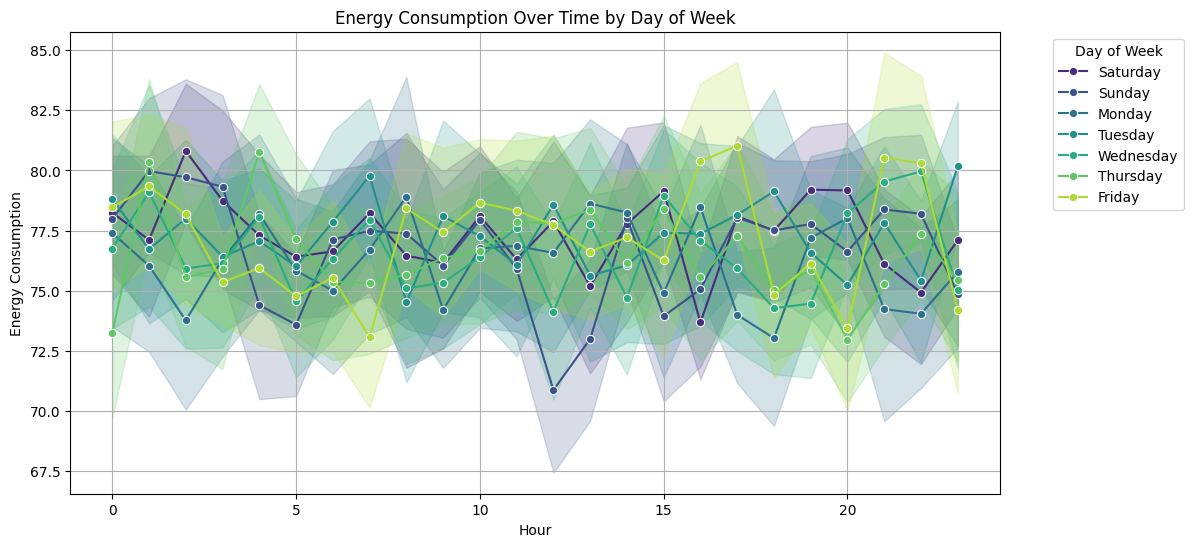

In [17]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Hour', y='EnergyConsumption', hue='DayOfWeek', palette='viridis', marker='o')
plt.title('Energy Consumption Over Time by Day of Week')
plt.xlabel('Hour')
plt.ylabel('Energy Consumption')
plt.legend(title='Day of Week', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

# Strip Plot for Energy Consumption by Hour


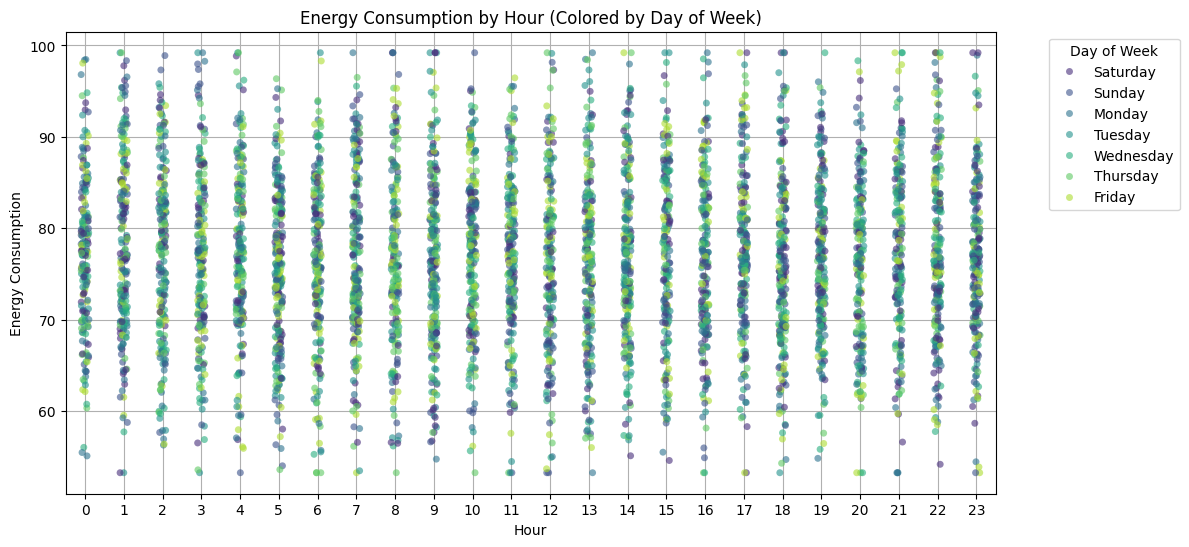

In [18]:
plt.figure(figsize=(12, 6))
sns.stripplot(data=df, x='Hour', y='EnergyConsumption', hue='DayOfWeek', palette='viridis', alpha=0.6)
plt.title('Energy Consumption by Hour (Colored by Day of Week)')
plt.xlabel('Hour')
plt.ylabel('Energy Consumption')
plt.legend(title='Day of Week', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> FUNCTION WITH ETL + SCALING</p>
</div>

In [20]:
categorical_features = ['Season', 'DayOfWeek', 'Holiday', 'HVACUsage', 'LightingUsage']
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)
df.head()

,Month,Hour,Temperature,Humidity,SquareFootage,Occupancy,RenewableEnergy,EnergyConsumption,Season_Spring,Season_Summer,Season_Winter,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,Holiday_Yes,HVACUsage_On,LightingUsage_On
0,1,0,25.139433,43.431581,1565.693999,5,2.774699,75.364373,False,False,True,False,True,False,False,False,False,False,True,False
1,1,1,27.731651,54.225919,1411.064918,1,21.831384,83.401855,False,False,True,False,True,False,False,False,False,False,True,True
2,1,2,28.704277,58.907658,1755.715009,2,6.764672,78.270888,False,False,True,False,True,False,False,False,False,False,False,False
3,1,3,20.080469,50.371637,1452.316318,1,8.623447,56.519850,False,False,True,False,True,False,False,False,False,False,False,True
4,1,4,23.097359,51.401421,1094.130359,9,3.071969,70.811732,False,False,True,False,True,False,False,False,False,False,True,False


In [21]:
# Define features (X) and target (y)
X = df.drop(columns=['EnergyConsumption'])  # Features
y = df['EnergyConsumption']  # Target

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(4000, 19)
(4000,)
(1000, 19)
(1000,)


In [ ]:

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# Train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
# Make predictions
y_pred = model.predict(X_test_scaled)

In [26]:
# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)


print("\nModel Performance:")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")


Model Performance:
Root Mean Squared Error (RMSE): 7.98
R-squared (R²): 0.24


# Feature Importance


In [27]:
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_}).sort_values(by='Importance', ascending=False)


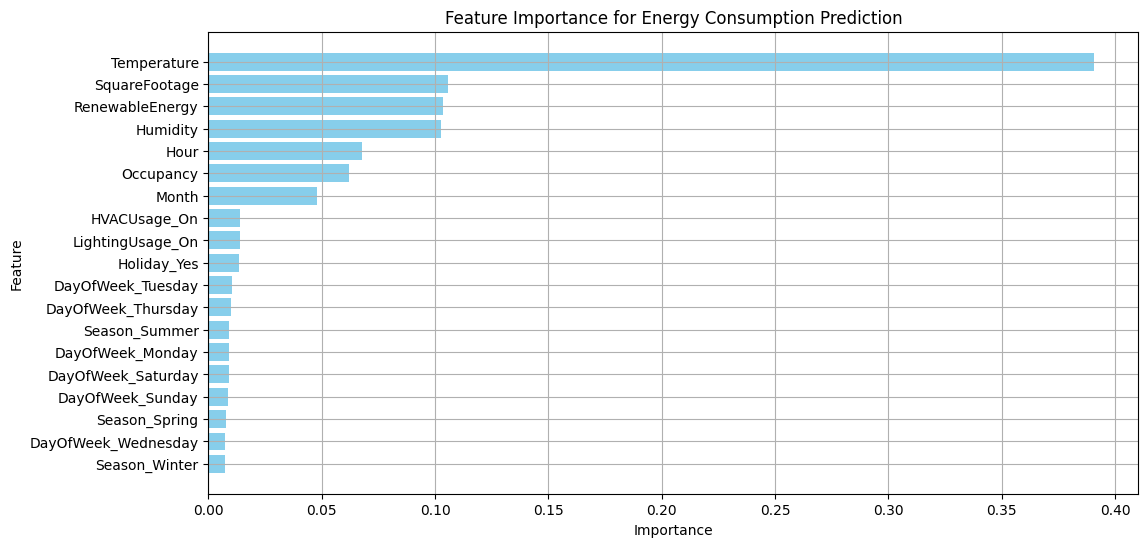

In [29]:
# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.title('Feature Importance for Energy Consumption Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid()
plt.show()